In [1]:
import sys
import os
import glob
import subprocess
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Configure Matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 6]
plt.rcParams['font.size'] = 12


In [2]:
def load_image_rgb(path):
    """Loads an image and converts BGR (OpenCV) to RGB (Matplotlib)."""
    if not os.path.exists(path):
        return None
    img = cv2.imread(path)
    if img is None: return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def run_flip_analysis(ref_path, test_path):
    """
    Robust version: Uses absolute paths and ignores non-fatal warnings.
    """
    # 1. Setup Absolute Paths
    # We want the output to be exactly where this notebook is
    current_dir = os.path.abspath(os.getcwd())
    temp_filename = "flip_temp" # Do not add .png here, FLIP adds it
    
    # Expected output file (FLIP 1.7+ typically defaults to PNG)
    expected_output = os.path.join(current_dir, f"{temp_filename}.png")
    
    # Clean up previous run if it exists
    if os.path.exists(expected_output):
        os.remove(expected_output)

    # 2. Locate FLIP Binary
    venv_bin = os.path.dirname(sys.executable)
    flip_executable = os.path.join(venv_bin, "flip")
    if not os.path.exists(flip_executable):
        flip_executable = "flip" # Fallback to PATH

    # 3. Construct Command
    cmd = [
        flip_executable,
        "--reference", os.path.abspath(ref_path),
        "--test", os.path.abspath(test_path),
        "--directory", current_dir,     # Force output to this folder
        "--basename", temp_filename,    # Output name (without extension)
        "--overwrite"
    ]
    
    # 4. Run without crashing on warnings (check=False)
    # We capture output to debug if needed, but don't stop execution
    proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
    
    # 5. Check if the file was actually created
    if os.path.exists(expected_output):
        # Success! Load the image
        img = cv2.imread(expected_output)
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # --- Debugging Block (Only runs if image is missing) ---
    print(f"⚠️  FLIP Output Missing for: {os.path.basename(test_path)}")
    print(f"   Looking for: {expected_output}")
    print(f"   Exit Code: {proc.returncode}")
    
    # Did it save with a different name? (e.g. flip_temp.png.png)
    possible_files = glob.glob(os.path.join(current_dir, "flip_temp*"))
    if possible_files:
        print(f"   Found similar files: {possible_files}")
    else:
        print("   No output files found.")
        print("   Tool Output:", proc.stderr)
        
    return None

def calculate_metrics(ref_img, test_img, ref_path, test_path):
    """Computes PSNR, SSIM, and FLIP."""
    # 1. PSNR (Signal Fidelity)
    psnr_val = cv2.PSNR(ref_img, test_img)
    
    # 2. SSIM (Structural Similarity)
    ssim_val = ssim(ref_img, test_img, channel_axis=2, data_range=255)
    
    # 3. FLIP (Perceptual Error)
    flip_map = run_flip_analysis(ref_path, test_path)
    
    mean_flip = 1.0 # Default max error
    if flip_map is not None:
        # Normalize 0-255 image to 0-1 float
        mean_flip = np.mean(flip_map) / 255.0
        
    return {
        "psnr": psnr_val,
        "ssim": ssim_val,
        "mean_flip": mean_flip,
        "flip_map": flip_map
    }

In [3]:
import matplotlib.gridspec as gridspec

def plot_visual_summary(ref_img, results_list):
    """
    Plots visuals only:
    - Top Row: Reference Image (Centered)
    - Subsequent Rows: Test Image | FLIP Error Map
    """
    num_tests = len(results_list)
    
    # Adjust figure height based on number of rows
    fig = plt.figure(figsize=(16, 4 + (4 * num_tests))) 
    
    # Grid: N+1 Rows, 2 Columns
    # Row 0: Reference (Spans 2 cols)
    # Rows 1..N: Test | FLIP
    gs = gridspec.GridSpec(num_tests + 1, 2, height_ratios=[1.2] + [1]*num_tests)
    
    # --- ROW 0: REFERENCE IMAGE ---
    ax_ref = fig.add_subplot(gs[0, :])
    ax_ref.imshow(ref_img)
    ax_ref.set_title("REFERENCE (GROUND TRUTH)", fontsize=16, fontweight='bold', pad=10)
    ax_ref.axis('off')
    
    # --- SUBSEQUENT ROWS ---
    for i, (quality, test_img, flip_map, _) in enumerate(results_list):
        row = i + 1 
        
        # Col 1: Compressed Image
        ax_test = fig.add_subplot(gs[row, 0])
        ax_test.imshow(test_img)
        ax_test.set_title(f"Compressed (Quality {quality})", fontsize=12, fontweight='bold')
        ax_test.axis('off')
        
        # Col 2: FLIP Map
        ax_flip = fig.add_subplot(gs[row, 1])
        if flip_map is not None:
            ax_flip.imshow(flip_map)
            ax_flip.set_title("FLIP Error Map", fontsize=12, fontweight='bold', color='darkred')
        else:
            ax_flip.text(0.5, 0.5, "FLIP Failed", ha='center')
        ax_flip.axis('off')

    plt.tight_layout()
    plt.show()

✅ Reference found: ../bin/release/csafe_heptane_302x302x302_uint8_f2_1.00.png
Processing 4 variations...



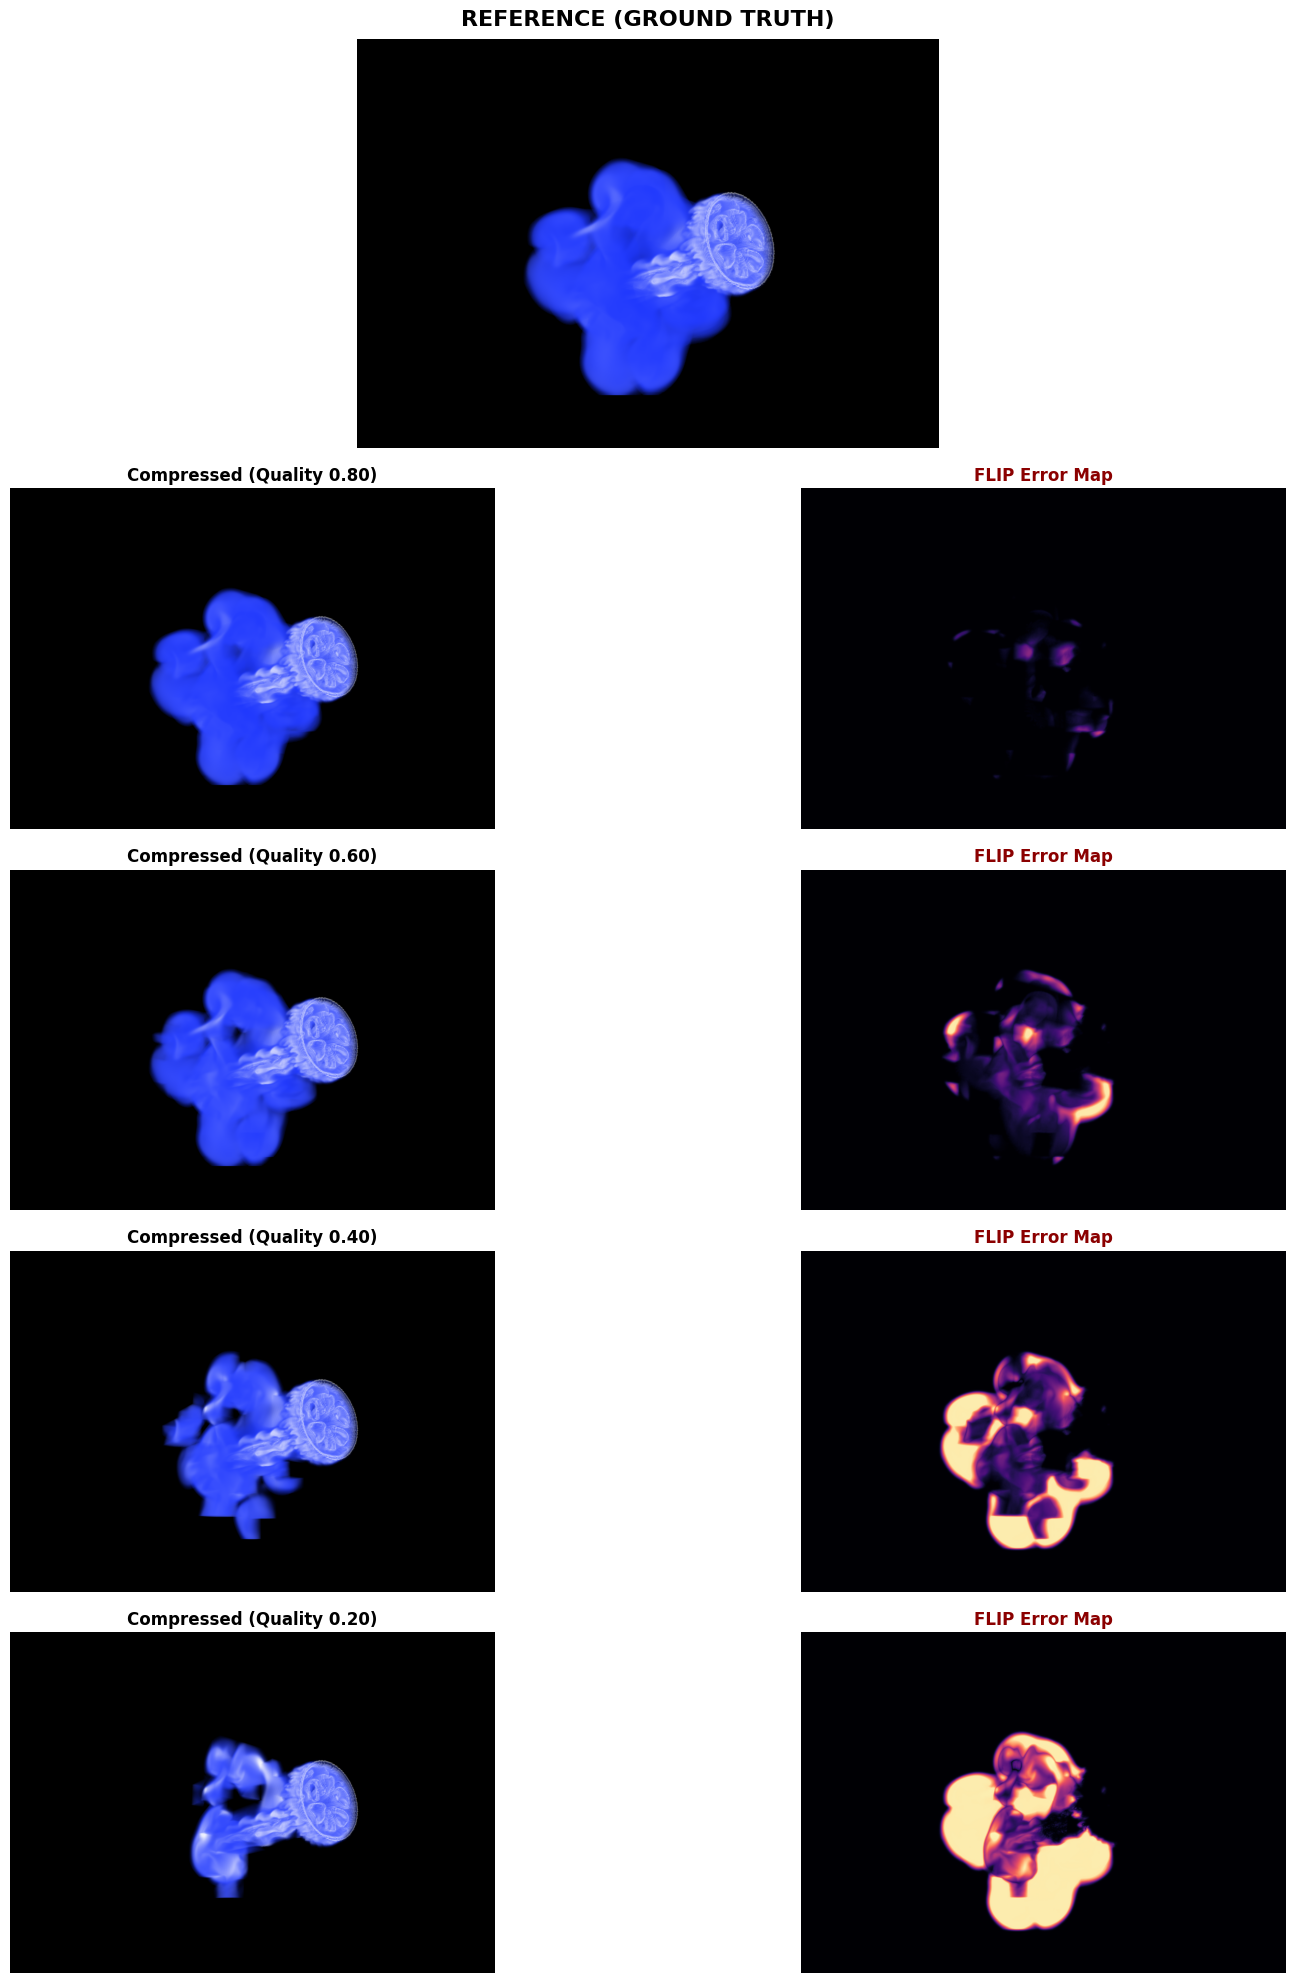


📊 QUANTITATIVE METRICS


,PSNR (dB),SSIM,Mean FLIP
Quality,,,
0.800000,47.0777,0.9993,0.0083
0.600000,30.2139,0.9891,0.0268
0.400000,20.0189,0.9454,0.0621
0.200000,16.6219,0.9072,0.0892


In [ ]:
# --- CONFIGURATION ---
input_dir = "../bin/release"  
dataset_name = "csafe_heptane_302x302x302_uint8" 
metric_type  = "f1" 
# ---------------------

ref_filename = os.path.join(input_dir, f"{dataset_name}_{metric_type}_1.00.png")

if os.path.exists(ref_filename):
    print(f"✅ Reference found: {ref_filename}")
    ref_img = load_image_rgb(ref_filename)
    
    # Find test files
    pattern = os.path.join(input_dir, f"{dataset_name}_{metric_type}_*.png")
    all_files = glob.glob(pattern)
    test_files = [f for f in all_files if "1.00.png" not in f]
    test_files.sort(reverse=True)
    
    results_collection = []
    table_data = []
    
    print(f"Processing {len(test_files)} variations...\n")
    
    for test_path in test_files:
        filename = os.path.basename(test_path)
        quality_label = filename.split('_')[-1].replace('.png', '')
        
        test_img = load_image_rgb(test_path)
        if ref_img.shape != test_img.shape:
            test_img = cv2.resize(test_img, (ref_img.shape[1], ref_img.shape[0]))
            
        m = calculate_metrics(ref_img, test_img, ref_filename, test_path)
        
        # Save for Visual Plot
        results_collection.append((quality_label, test_img, m['flip_map'], m))
        
        # Save for Excel Table
        table_data.append({
            "Quality": float(quality_label),
            "PSNR (dB)": m['psnr'],
            "SSIM": m['ssim'],
            "Mean FLIP": m['mean_flip']
        })

    # 1. SHOW VISUALS
    if results_collection:
        plot_visual_summary(ref_img, results_collection)
    
    # 2. SHOW DATA TABLE (The "Excel" Part)
    if table_data:
        print("\n📊 QUANTITATIVE METRICS")
        df = pd.DataFrame(table_data)
        df = df.sort_values("Quality", ascending=False).set_index("Quality")
        
        # Style looks like Excel with heatmaps
        styled_df = df.style.background_gradient(cmap='RdYlGn', subset=['PSNR (dB)', 'SSIM'])\
                            .background_gradient(cmap='RdYlGn_r', subset=['Mean FLIP'])\
                            .format("{:.4f}")
        display(styled_df)
else:
    print("Reference image missing.")